# ANALISIS EXPLORATORIO DE DATOS (EDA)

## 1-CONFIGURACION Y CARGA DE DATOS

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker # Para formatear ejes

# Asegurar de que la ruta sea correcta dentro de la estructura 'Cookiecutter'
try:
    df = pd.read_csv('/tecnicatura en cd e ia/2025/SEGUNDO AÑO/2do año 1er cuatrimestre/aprendizaje automatico/PROYECTOS AA/actividades de ML/PARCIAL_AA_2025/data/02-dataset listo para EDA/impom24_listo_para_EDA.csv', decimal='.')
    print("Datos cargados correctamente.")
    print(f"Instancias: {len(df)}, Características: {len(df.columns)}")
except FileNotFoundError:
    print("Error: Asegúrate de que el archivo CSV está en la carpeta '/tecnicatura en cd e ia/2025/SEGUNDO AÑO/2do año 1er cuatrimestre/aprendizaje automatico/PROYECTOS AA/actividades de ML/PARCIAL_AA_2025/data/02-dataset listo para EDA/'.")

# Convertir tipos de datos categóricos y temporales
df['NCM_8_digitos'] = df['NCM_8_digitos'].astype(str)
df['Pais_Origen_Cod'] = df['Pais_Origen_Cod'].astype(str)

# Crear la columna de fecha para el análisis de series de tiempo
# Se asume que el año es 2024 (o el año del dataset)
df['Fecha'] = pd.to_datetime(df['Año'].astype(str) + '-' + df['mes'].astype(str) + '-01')

df.head()

Datos cargados correctamente.
Instancias: 347874, Características: 12


,Año,mes,NCM_8_digitos,Pais_Origen_Cod,Peso_Neto_kg,FOB(USD),Flete(USD),Seguro(USD),CIF(USD),Precio_Unitario_USD_kg,NCM_2_digitos,NCM_4_digitos,Fecha
0,2024,1,1012100,200,500.0,6000.00,3500.00,47.50,9547.50,12.000000,1,101,2024-01-01
1,2024,1,1012100,212,2500.0,19500.00,26000.01,455.01,45955.02,7.800000,1,101,2024-01-01
2,2024,1,1012100,417,300.0,33490.76,3256.80,367.48,37115.04,111.635867,1,101,2024-01-01
3,2024,1,1012900,200,450.0,5000.00,2500.00,75.00,7575.00,11.111111,1,101,2024-01-01
4,2024,1,1012900,423,1000.0,9800.00,6513.60,168.27,16481.87,9.800000,1,101,2024-01-01


# 2-Análisis del target: CIF(USD)

## El objetivo es entender la variable que estamos tratando de predecir.

### A. Distribución del Valor CIF

Analizamos la distribución para ver si es sesgada (lo cual es muy común en datos económicos).

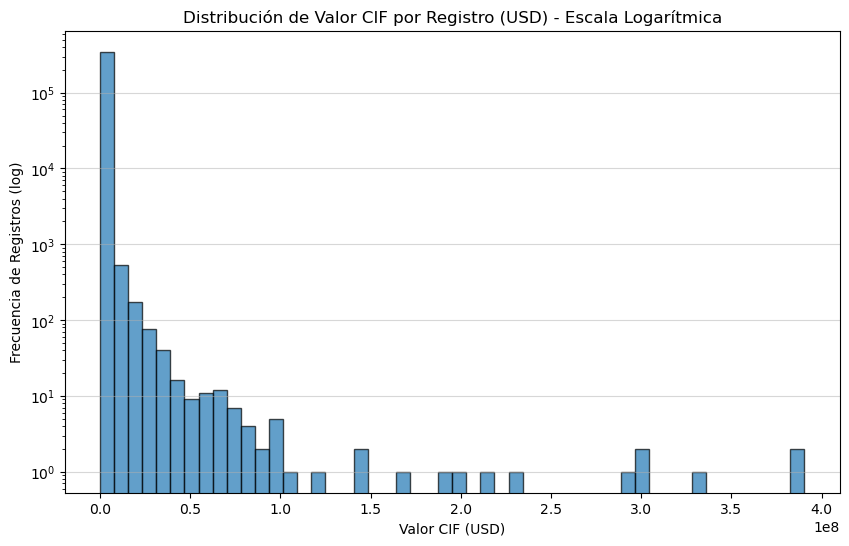

Estadísticas Descriptivas Clave de Valor_CIF_USD:
count    3.478740e+05
mean     1.747057e+05
std      2.095671e+06
min      1.000000e-02
25%      1.132325e+03
50%      9.506790e+03
75%      5.833669e+04
max      3.904482e+08
Name: CIF(USD), dtype: float64


In [27]:
plt.figure(figsize=(10, 6))
df['CIF(USD)'].plot(kind='hist', bins=50, edgecolor='black', alpha=0.7)
plt.yscale('log') # Usamos escala logarítmica para ver la cola de valores altos
plt.title('Distribución de Valor CIF por Registro (USD) - Escala Logarítmica')
plt.xlabel('Valor CIF (USD)')
plt.ylabel('Frecuencia de Registros (log)')
plt.grid(axis='y', alpha=0.5)
plt.show()

print("Estadísticas Descriptivas Clave de Valor_CIF_USD:")
print(df['CIF(USD)'].describe())

## Insight: La distribución será altamente sesgada a la derecha (muchos registros con valores bajos y pocos con valores muy altos). Esto indica que los pocos productos de alto valor son muy importantes, y el modelo de regresión deberá ser robusto a los outliers.

### B. Serie de Tiempo Agregada (Tendencia y Estacionalidad)

Agregamos los datos para visualizar el comportamiento mensual total.

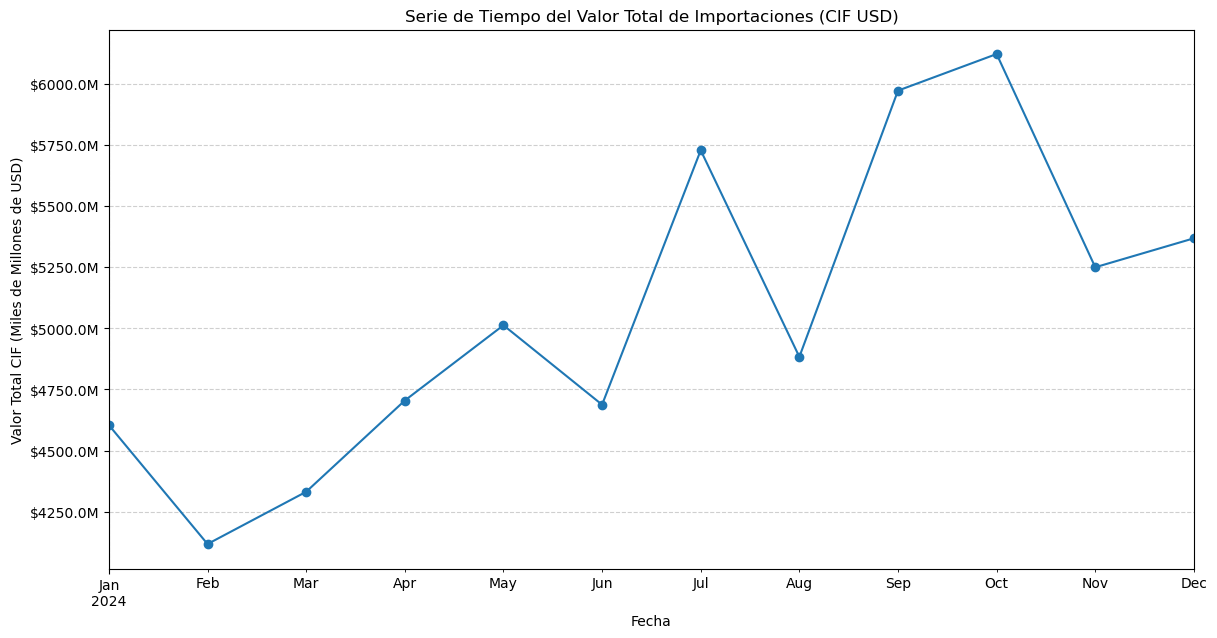

In [29]:
# Agrupamos por mes para obtener el total de importaciones
serie_tiempo = df.groupby('Fecha')['CIF(USD)'].sum()

plt.figure(figsize=(14, 7))
serie_tiempo.plot(marker='o', linestyle='-')
plt.title('Serie de Tiempo del Valor Total de Importaciones (CIF USD)')
plt.xlabel('Fecha')
plt.ylabel('Valor Total CIF (Miles de Millones de USD)')
plt.grid(True, linestyle='--', alpha=0.6)

# Formato del eje Y para mostrar valores grandes en notación económica
def millones(x, pos):
    'Formatea el valor en millones'
    return f'${x*1e-6:.1f}M'

formatter = ticker.FuncFormatter(millones)
plt.gca().yaxis.set_major_formatter(formatter)

plt.show()

## Insight:

### Tendencia general (Trend)

La tendencia se refiere a la dirección a largo plazo de la serie.

Considerando el valor inicial en enero (USS 4.6000 millones aprox) y el valor final en diciembre (USS 5,400 millones aprox), la serie de tiempo muestra una tendencia ligeramente positiva o alcista a lo largo del año.

Evidencia: El nivel general de las importaciones (CIF) es significativamente más alto al final del año (octubre, noviembre, diciembre) que a principios (enero, febrero, marzo), a pesar de las fluctuaciones mensuales. El valor máximo de la serie es el doble del valor mínimo, lo que indica un fuerte crecimiento durante el periodo.

### Estacionalidad y ciclicidad

La estacionalidad se refiere a patrones que se repiten en periodos fijos y conocidos (como mensual, trimestral o anualmente). Aunque solo hay un año de datos, los patrones de alto y bajo nivel en meses específicos sugieren una posible estacionalidad, que se confirmaría con datos de varios años.

En el gráfico se revela un patrón de dos picos (bimodal) y un valle que es común en las series de tiempo económicas:

1. Valle de principios de año (Baja estacionalidad)

    Periodo: Febrero-Marzo.

    Comportamiento: Hay una caída notable en Febrero (U$S 4.250 millones aprox), seguido de un repunte ligero en Marzo. Esta baja al comienzo del año es a menudo estacional, coincidiendo con menos días hábiles o un período de menor actividad económica (como el impacto de las festividades de fin de año o las "vacaciones de verano" en ciertas economías).

2. Primer pico y asentamiento

    Periodo: Abril-Mayo.

    Comportamiento: Un fuerte crecimiento entre abril (USS 4.750 millones aprox) y mayo (U$S 5.000 millones aprox), seguido de un retroceso en junio. Esto puede reflejar un primer pico de demanda o el momento en que se procesan y contabilizan las importaciones de insumos clave.

3. Segundo y mayor pico (Alta estacionalidad)

    Periodo: Julio y Septiembre-Octubre.

    Comportamiento: Este es el patrón más fuerte:

   * Julio registra un pico significativo (USS 5.750 millones aprox).
   * Luego, tras un bache en agosto, las importaciones experimentan un crecimiento explosivo para alcanzar los máximos del año en Septiembre (poco menos de USS 6.000 millones) y Octubre (mas de U$S 6.000 millones).

        Este comportamiento es altamente estacional y se relaciona típicamente con la preparación para el pico de ventas de fin de año (Navidad, "Black Friday", etc.) , donde las empresas acumulan inventario importado para satisfacer la demanda de los últimos meses del año.

4. Cierre de año

    Comportamiento: Una baja en noviembre y un repunte en diciembre. La baja de noviembre (USS 5.250) después del máximo de octubre es una corrección esperada, mientras que el repunte de diciembre (U$S 5.400) sugiere un movimiento final de stock o importaciones de última hora.

# 3. Análisis de Features Categóricas Clave

## Identificamos a los principales drivers de las importaciones.


### A. Top 10 Países de Origen (Contribución al valor)

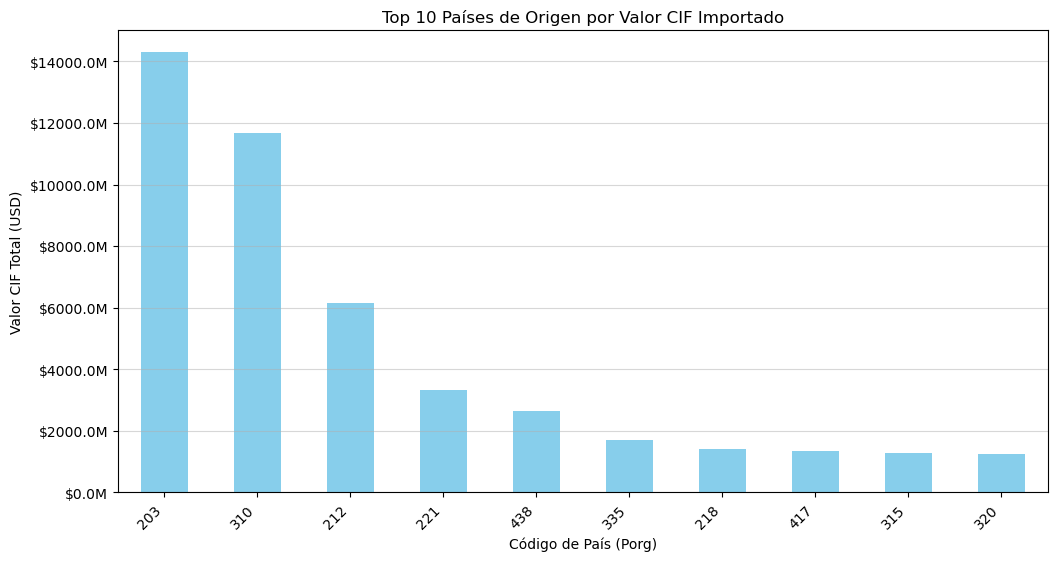


Países clave y su peso en el total:
Pais_Origen_Cod
203    23.506314
310    19.182364
212    10.139153
221     5.452867
438     4.363431
335     2.821771
218     2.343288
417     2.193154
315     2.130740
320     2.049221
Name: CIF(USD), dtype: float64


In [31]:
top_paises = df.groupby('Pais_Origen_Cod')['CIF(USD)'].sum().nlargest(10)

plt.figure(figsize=(12, 6))
top_paises.plot(kind='bar', color='skyblue')
plt.title('Top 10 Países de Origen por Valor CIF Importado')
plt.xlabel('Código de País (Porg)')
plt.ylabel('Valor CIF Total (USD)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.5)
plt.gca().yaxis.set_major_formatter(formatter) # Usa el mismo formato de millones
plt.show()

print("\nPaíses clave y su peso en el total:")
print(top_paises / df['CIF(USD)'].sum() * 100)

## Insight: Este análisis nos muestra que una pequeña cantidad de países (probablemente Brasil, China, EE. UU.) dominan el valor de las importaciones. Estos países deben ser tratados como features categóricas de alta importancia, posiblemente usando One-Hot Encoding en el modelado.

### B. Top 10 Capítulos arancelarios (NCM de 2 Dígitos)

Los capítulos arancelarios (NCM_2_digitos) representan categorías amplias (ej. 84 para Máquinas, 87 para Vehículos).

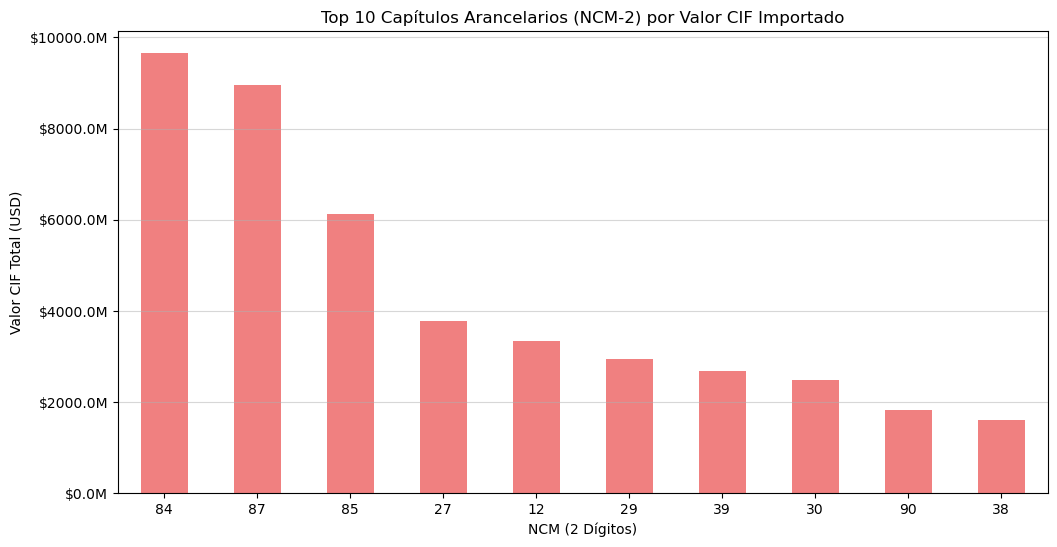


Capítulos NCM clave y su peso en el total:
NCM_2_digitos
84    15.885854
87    14.739088
85    10.065373
27     6.216052
12     5.492669
29     4.861670
39     4.425033
30     4.091908
90     3.017537
38     2.645439
Name: CIF(USD), dtype: float64


In [33]:
top_ncm = df.groupby('NCM_2_digitos')['CIF(USD)'].sum().nlargest(10)

plt.figure(figsize=(12, 6))
top_ncm.plot(kind='bar', color='lightcoral')
plt.title('Top 10 Capítulos Arancelarios (NCM-2) por Valor CIF Importado')
plt.xlabel('NCM (2 Dígitos)')
plt.ylabel('Valor CIF Total (USD)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.5)
plt.gca().yaxis.set_major_formatter(formatter)
plt.show()

print("\nCapítulos NCM clave y su peso en el total:")
print(top_ncm / df['CIF(USD)'].sum() * 100)

## Insight: Esto permite segmentar el problema. Los NCMs que concentran la mayor parte del valor (ej. Bienes Intermedios o Bienes de Capital) son donde el modelo de regresión tendrá el mayor impacto predictivo.

# 4. Conclusión del EDA

## El EDA confirma que el problema de regresión es complejo debido a:

### * Distribución sesgada: El target (CIF(USD)) requiere modelos que manejen bien los outliers y la heterocedasticidad (ej. SVR o Transformaciones Logarítmicas).

### * Influencia categórica Fuerte: Una pequeña cantidad de Países y NCMs concentran la mayor parte del valor, justificando la inclusión de estas variables categóricas.

### * Componente temporal: Existe una tendencia y estacionalidad claras que deben ser capturadas por el modelo (ej. usando la variable Mes).

# Estos insights serán la base para justificar el modelo de regresión en la próxima entrega.